# Assignment 4: Predicting Outcomes with Simple & Multiple Linear Regression

**Dataset:** Insurance Charges
- Source: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
- Target variable: `charges`

This notebook builds:
1. A **Simple Linear Regression** model (one feature)
2. A **Multiple Linear Regression** model (multiple features)

Then we compare MAE, RMSE, and R-Squared scores.

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

# Load data directly from URL
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
display(df.head())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


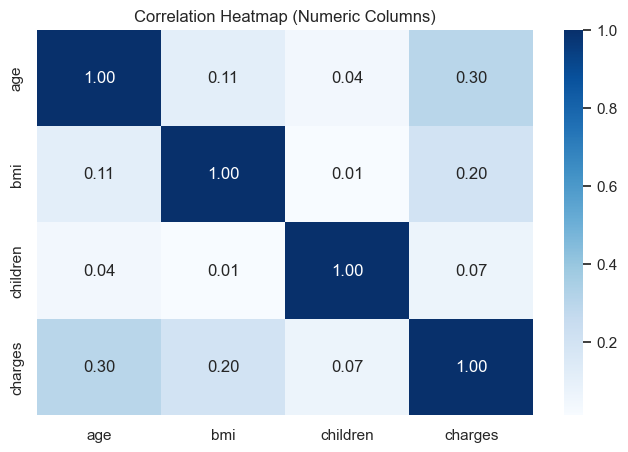

In [2]:
# Quick check of numeric relationships
display(df.describe())

plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

## Part 2: Simple Linear Regression
For a simple model, we use only **bmi** to predict **charges**.

Simple Linear Regression Metrics
MAE  : 9784.65
RMSE : 12210.04
R^2  : 0.0397


c:\Users\Shiv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


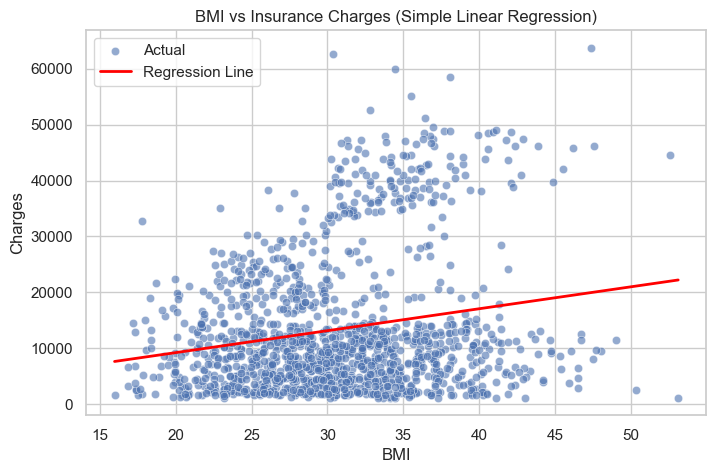

In [3]:
# One feature only
X_simple = df[["bmi"]]
y = df["charges"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)

mae_s = mean_absolute_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s = r2_score(y_test_s, y_pred_s)

print("Simple Linear Regression Metrics")
print(f"MAE  : {mae_s:.2f}")
print(f"RMSE : {rmse_s:.2f}")
print(f"R^2  : {r2_s:.4f}")

# Required style of plot: feature vs target
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["bmi"], y=df["charges"], alpha=0.6, label="Actual")

x_line = np.linspace(df["bmi"].min(), df["bmi"].max(), 200).reshape(-1, 1)
y_line = simple_model.predict(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression Line")

plt.title("BMI vs Insurance Charges (Simple Linear Regression)")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend()
plt.show()

## Part 3: Multiple Linear Regression
Now we add more features to improve prediction.

Features used: `age`, `bmi`, `children`, `smoker`, `sex`, `region` (after encoding categorical columns).

Multiple Linear Regression Metrics
MAE  : 4181.19
RMSE : 5796.28
R^2  : 0.7836

Top Coefficients by absolute value:


smoker_yes          23651.128856
region_southwest     -809.799354
region_southeast     -657.864297
children              425.278784
region_northwest     -370.677326
bmi                   337.092552
age                   256.975706
sex_male              -18.591692
dtype: float64

Intercept: -11931.22

Multiple Linear Regression Equation:
charges = (256.98 * age) + (337.09 * bmi) + (425.28 * children) + (-18.59 * sex_male) + (23651.13 * smoker_yes) + (-370.68 * region_northwest) + (-657.86 * region_southeast) + (-809.80 * region_southwest) + (-11931.22)


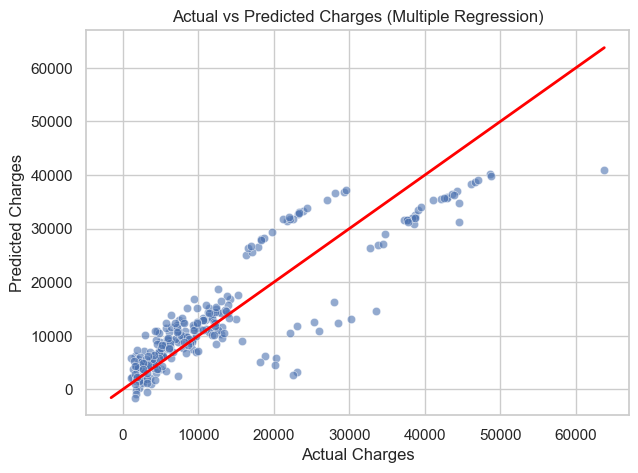

In [4]:
# Convert categorical variables into numeric dummy columns
df_multi = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

X_multi = df_multi.drop(columns=["charges"])
y_multi = df_multi["charges"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_m = multi_model.predict(X_test_m)

mae_m = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
r2_m = r2_score(y_test_m, y_pred_m)

print("Multiple Linear Regression Metrics")
print(f"MAE  : {mae_m:.2f}")
print(f"RMSE : {rmse_m:.2f}")
print(f"R^2  : {r2_m:.4f}")

# Show model equation
coef_series = pd.Series(multi_model.coef_, index=X_multi.columns).sort_values(key=np.abs, ascending=False)
print("\nTop Coefficients by absolute value:")
display(coef_series.head(10))
print(f"Intercept: {multi_model.intercept_:.2f}")

equation_parts = [f"({coef:.2f} * {name})" for name, coef in zip(X_multi.columns, multi_model.coef_)]
equation = "charges = " + " + ".join(equation_parts) + f" + ({multi_model.intercept_:.2f})"
print("\nMultiple Linear Regression Equation:")
print(equation)

# Actual vs predicted plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test_m, y=y_pred_m, alpha=0.6)
line_min = min(y_test_m.min(), y_pred_m.min())
line_max = max(y_test_m.max(), y_pred_m.max())
plt.plot([line_min, line_max], [line_min, line_max], color="red", linewidth=2)
plt.title("Actual vs Predicted Charges (Multiple Regression)")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

In [5]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    "Model": ["Simple (bmi only)", "Multiple (all selected features)"],
    "MAE": [mae_s, mae_m],
    "RMSE": [rmse_s, rmse_m],
    "R2": [r2_s, r2_m]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Simple (bmi only),9784.652596,12210.039191,0.039702
1,Multiple (all selected features),4181.194474,5796.284659,0.783593


## Part 4: Analysis and Comparison

1. **Simple vs. Multiple equation**
   - Simple model used one slope value for `bmi` plus an intercept.
   - Multiple model uses one coefficient for each feature (`age`, `bmi`, `children`, smoker/sex/region dummies) plus one intercept.

2. **Accuracy and error comparison**
   - Compare MAE, RMSE, and R^2 from the table above.
   - Lower MAE and RMSE mean better predictions.
   - R^2 closer to 1 means the model explains more variance in charges.

3. **Did adding variables help?**
   - Yes, usually the multiple model performs better here because insurance charges are affected by more than BMI alone.
   - Especially, the `smoker` variable often has a strong effect and improves model fit a lot.

4. **One extra feature that could improve further**
   - A useful extra variable could be a medical-risk score (for example: blood pressure, diabetes status, or chronic disease count).
   - This could capture health risk differences that are not fully explained by age/BMI/children alone.